In [52]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import pickle
import pathlib as Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [53]:
# load data
sys.path.append("../")

from src.data_loader import load_cement_data

df = load_cement_data()
df.head()

,date,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
1,2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
2,2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448
3,2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
4,2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448


In [54]:
# prepare one site for modeling
site_id = 'SITE_001'

site_df = df[df['site_id'] == site_id].copy()
site_df = site_df.set_index('date')
site_df = site_df.sort_values('date')

y = site_df['consumed_tonnes']

x = site_df[['planned_pour_tonnes', 'rain_mm', 'avg_temp_c']]

site_df.head()

,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
date,,,,,,,,,,,,
2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448
2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448


In [55]:
# split train test data
split_index = int(len(site_df) * 0.8)
y_train, X_train = y.iloc[:split_index], x.iloc[:split_index]
y_test, X_test = y.iloc[split_index:], x.iloc[split_index:]

print(len(y_train), len(y_test))

876 220


In [56]:
# simple GRID search for SARIMAX parameters
best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for p in (0, 2):
    for d in (0, 2):
        for q in (0, 2):
            for P in (0, 2):
                for D in (0, 2):
                    for Q in (0, 2):
                        try:
                            model = SARIMAX(
                                y_train, 
                                exog=X_train,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 7),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            results = model.fit(disp=False)

                            if results.aic < best_aic:
                                best_aic = results.aic
                                best_order = (p, d, q)
                                best_seasonal_order = (P, D, Q, 7)
                                best_model = results


                        except:
                            pass

print(f'Best SARIMAX model order: {best_order}, seasonal order: {best_seasonal_order}, AIC: {best_aic}') 

Best SARIMAX model order: (0, 0, 2), seasonal order: (0, 2, 2, 7), AIC: 6696.319002559316


In [57]:
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                   consumed_tonnes   No. Observations:                  876
Model:             SARIMAX(0, 0, 2)x(0, 2, 2, 7)   Log Likelihood               -3340.160
Date:                           Fri, 17 Jul 2026   AIC                           6696.319
Time:                                   09:20:17   BIC                           6734.234
Sample:                               01-01-2022   HQIC                          6710.846
                                    - 05-25-2024                                         
Covariance Type:                             opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
planned_pour_tonnes     0.5499      0.036     15.395      0.000       0.480       0.620
rain_mm                -0.8958      0.072    -12.501      0.000      -1.036      -0.755
avg_temp_c              0.0560      0.053      1.048      0.295      -0.049       0.161
ma.L1                   0.0920      0.036      2.555      0.011       0.021       0.163
ma.L2                   0.0067      0.035      0.193      0.847      -0.061       0.075
ma.S.L7                -1.9689      2.438     -0.808      0.419      -6.748       2.810
ma.S.L14                0.9688      2.364      0.410      0.682      -3.664       5.601
sigma2                145.8911    353.768      0.412      0.680    -547.482     839.264
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                28.06
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               0.97   Skew:                            -0.41
Prob(H) (two-sided):                  0.79   Kurtosis:                         2.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [58]:
# perform 8 week forecast using the best SARIMAX model

forecast_horizon = 56

y_test_8w = y_test.iloc[:forecast_horizon]
X_test_8w = X_test.iloc[:forecast_horizon]

forecast = best_model.predict(
  start=y_test_8w.index[0],
  end=y_test_8w.index[-1],
  exog=X_test_8w
)

forecast.head()

2024-05-26    32.655666
2024-05-27    40.070521
2024-05-28    13.698890
2024-05-29    28.744347
2024-05-30    35.838829
Freq: D, Name: predicted_mean, dtype: float64

In [59]:
# Metrics for SARIMAX model for SITE_001

mask = y_test_8w != 0

mape = np.mean(
  np.abs((y_test_8w[mask] - forecast[mask]) / y_test_8w[mask])
) * 100

rmse = np.sqrt(
  mean_squared_error(y_test_8w[mask], forecast[mask])
)

print("MAPE:", round(mape, 2))
print("RMSE:", round(rmse, 2))

MAPE: 53.88
RMSE: 13.21


In [60]:
# Sarimax metrics for all sites
sarimax_sites_metrics = []
sarimax_sites_predictions = []

for site_id in df['site_id'].unique():
  try:
    site_df = df[df['site_id'] == site_id].copy()
    site_df = site_df.set_index('date')
    site_df = site_df.sort_values('date')

    y = site_df['consumed_tonnes']
    x = site_df[['planned_pour_tonnes', 'rain_mm', 'avg_temp_c']]

    split_index = int(len(site_df) * 0.8)
    y_train, X_train = y.iloc[:split_index], x.iloc[:split_index]
    y_test, X_test = y.iloc[split_index:], x.iloc[split_index:]

    sarimax_model = SARIMAX(
        y_train, 
        exog=X_train,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = sarimax_model.fit(disp=False)

    forecast_horizon = 56

    y_test_8w = y_test.iloc[:forecast_horizon]
    X_test_8w = X_test.iloc[:forecast_horizon]

    forecast = results.predict(
      start=y_test_8w.index[0],
      end=y_test_8w.index[-1],
      exog=X_test_8w
    )

    site_predictions = pd.DataFrame({
      'site_id': site_id,
      'date': y_test_8w.index,
      'actual_consumed_tonnes': y_test_8w.values,
      'forecasted_consumed_tonnes': forecast.values
    })

    sarimax_sites_predictions.append(site_predictions)

    mask = y_test_8w != 0

    mape = np.mean(
      np.abs((y_test_8w[mask] - forecast[mask]) / y_test_8w[mask])
    ) * 100

    rmse = np.sqrt(
      mean_squared_error(y_test_8w[mask], forecast[mask])
    )

    sarimax_sites_metrics.append({
      'site_id': site_id,
      'MAPE': round(mape, 2),
      'RMSE': round(rmse, 2)
    })

  except Exception as e:
    print(f"Error processing site {site_id}: {e}")

sarimax_sites_metrics_df = pd.DataFrame(sarimax_sites_metrics)

overall_mape = sarimax_sites_metrics_df['MAPE'].mean()
overall_rmse = sarimax_sites_metrics_df['RMSE'].mean()

overall_row = pd.DataFrame([{
    'site_id': 'Overall',
    'MAPE': round(overall_mape, 2),
    'RMSE': round(overall_rmse, 2)
}])

sarimax_sites_metrics_df = pd.concat(
  [sarimax_sites_metrics_df, overall_row], 
  ignore_index=True
)

sarimax_sites_metrics_df 

sarimax_sites_predictions_df = pd.concat(
  sarimax_sites_predictions, 
  ignore_index=True
)

sarimax_sites_predictions_df

,site_id,date,actual_consumed_tonnes,forecasted_consumed_tonnes
0,SITE_001,2024-05-26,54.68,32.655666
1,SITE_001,2024-05-27,28.18,40.070521
2,SITE_001,2024-05-28,0.00,13.698890
3,SITE_001,2024-05-29,40.29,28.744347
4,SITE_001,2024-05-30,32.99,35.838829
...,...,...,...,...
1675,SITE_030,2024-07-16,34.03,25.636905
1676,SITE_030,2024-07-17,14.82,34.600801
1677,SITE_030,2024-07-18,40.22,39.669121
1678,SITE_030,2024-07-19,38.43,29.774230


In [61]:
sarimax_sites_metrics_df

,site_id,MAPE,RMSE
0,SITE_001,53.88,13.21
1,SITE_002,3.78,0.50
2,SITE_003,27.52,10.44
3,SITE_004,3.35,0.44
4,SITE_005,30.60,11.85
5,SITE_006,25.61,10.04
6,SITE_007,37.55,10.95
7,SITE_008,35.72,11.57
8,SITE_009,3.37,0.48
9,SITE_010,45.32,13.46


In [62]:
# Top 3 sites by total Consumed Tonnes
top_3_sites = (
  df.groupby('site_id')['consumed_tonnes']
  .sum()
  .sort_values(ascending=False)
  .head(3)
  .index
)

top_3_sites 

Index(['SITE_025', 'SITE_010', 'SITE_018'], dtype='object', name='site_id')

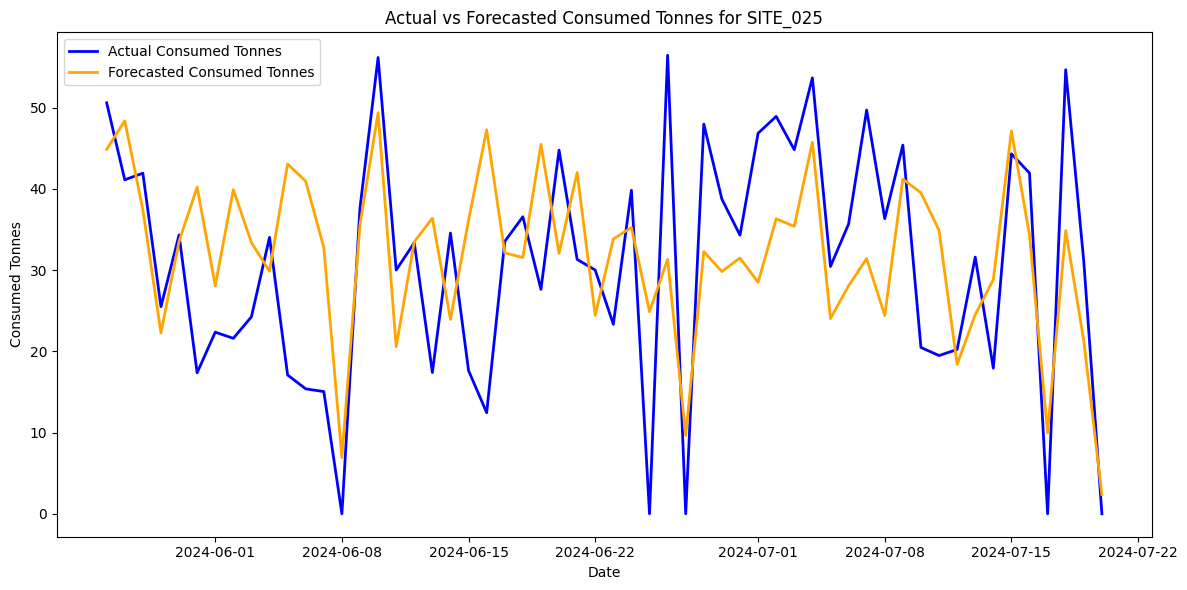

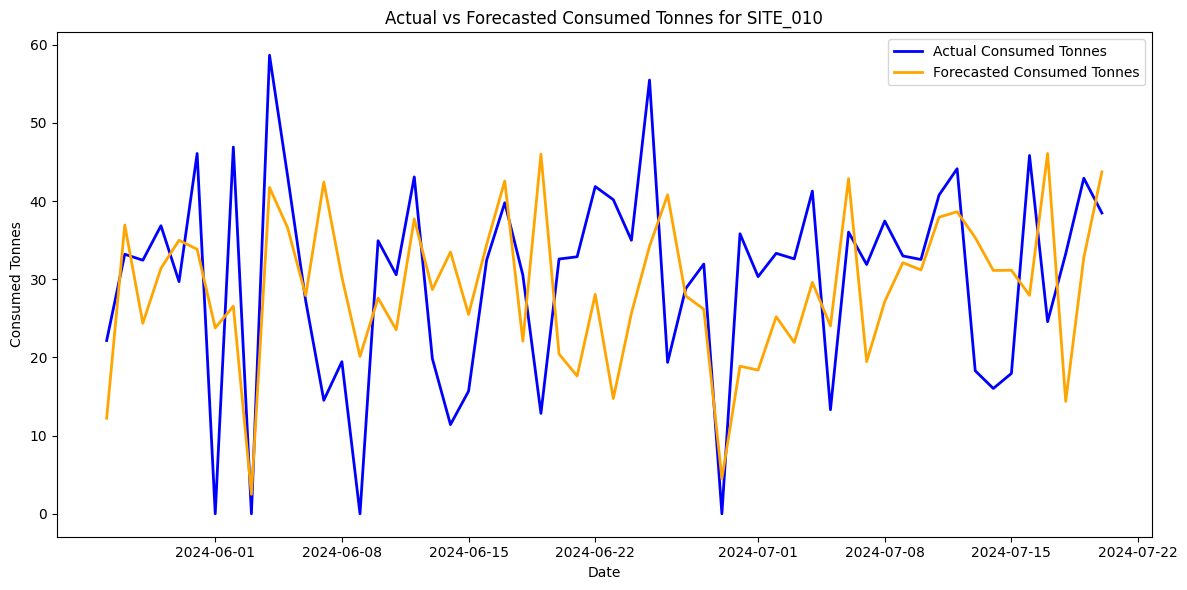

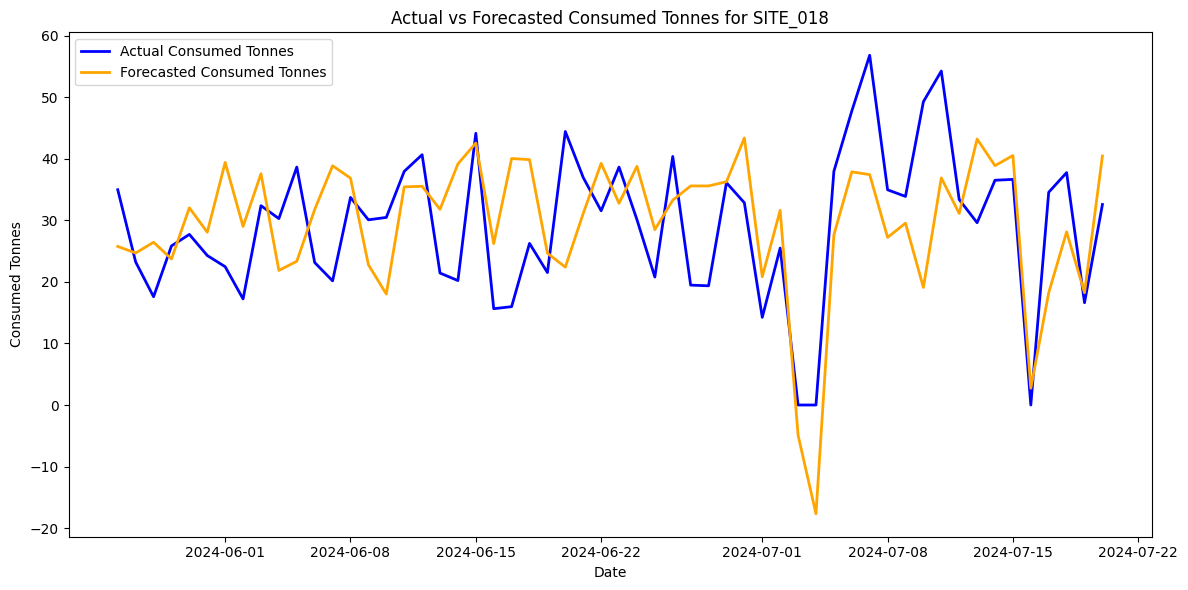

In [63]:
# Visualize predictions vs actuals for top 3 sites
for site_id in top_3_sites:
  plot_df = sarimax_sites_predictions_df[
    sarimax_sites_predictions_df['site_id'] == site_id
  ].copy()

  plot_df = plot_df.set_index('date')

  plt.figure(figsize=(12, 6))

  plt.plot(
    plot_df.index,
    plot_df["actual_consumed_tonnes"],
    label="Actual Consumed Tonnes",
    linewidth=2,
    color='blue'
  )
  plt.plot(
    plot_df.index,
    plot_df["forecasted_consumed_tonnes"],
    label="Forecasted Consumed Tonnes",
    linewidth=2,
    color='orange'
  )

  plt.title(f"Actual vs Forecasted Consumed Tonnes for {site_id}")
  plt.xlabel("Date")
  plt.ylabel("Consumed Tonnes")
  plt.legend()
  plt.tight_layout()
  plt.show()

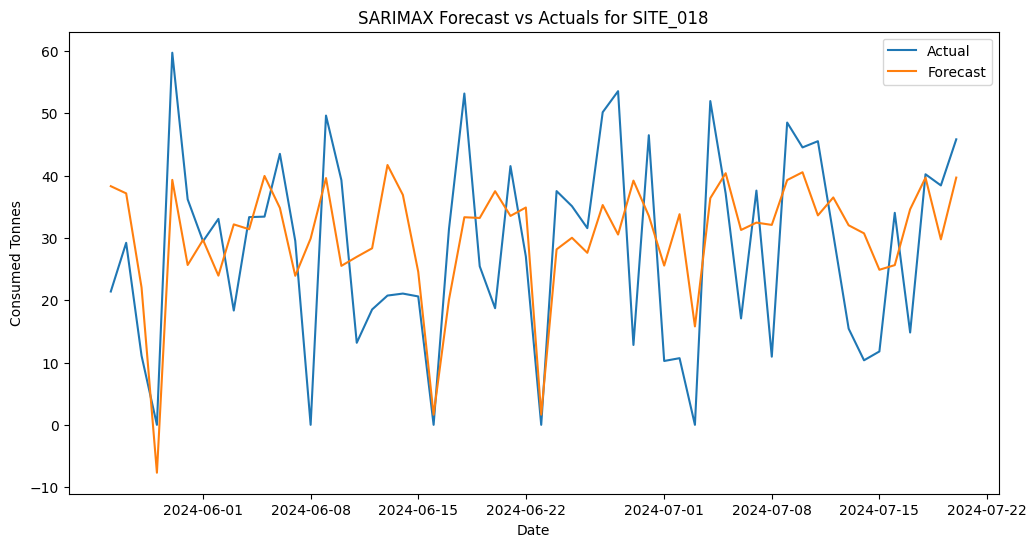

In [64]:
# Plot forecast vs actuals

plt.figure(figsize=(12, 6))

plt.plot(y_test_8w.index, y_test_8w, label='Actual')
plt.plot(y_test_8w.index, forecast, label='Forecast')

plt.title(f'SARIMAX Forecast vs Actuals for {site_id}')
plt.xlabel('Date')
plt.ylabel('Consumed Tonnes')
plt.legend()
plt.show()

In [65]:
# Model diagnostics
# get residuals
residuals = best_model.resid

# Ljung-Box test for autocorrelation
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)

# Jarque-Bera test for normality
jb_stat, jb_pvalue = jarque_bera(residuals)

# Diagnostic summary table
diagnostic_summary = pd.DataFrame({
  "diagnostic": [
    "Residuals Mean",
    "Residual Standard Deviation",
    "ljung_box p-value (10 lags)",
    "jarque_bera statistic",
    "jarque_bera p-value"
  ],
  "value": [
    residuals.mean(),
    residuals.std(),
    lb_test['lb_pvalue'].iloc[0],
    jb_stat,
    jb_pvalue
  ]
})

diagnostic_summary

,diagnostic,value
0,Residuals Mean,0.124986
1,Residual Standard Deviation,13.213435
2,ljung_box p-value (10 lags),0.573660
3,jarque_bera statistic,14.316922
4,jarque_bera p-value,0.000778


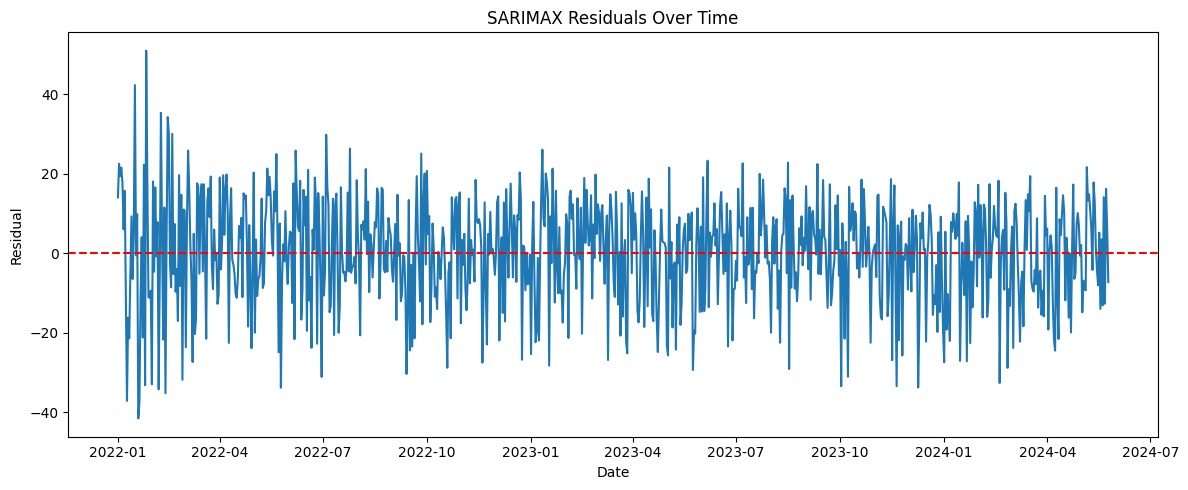

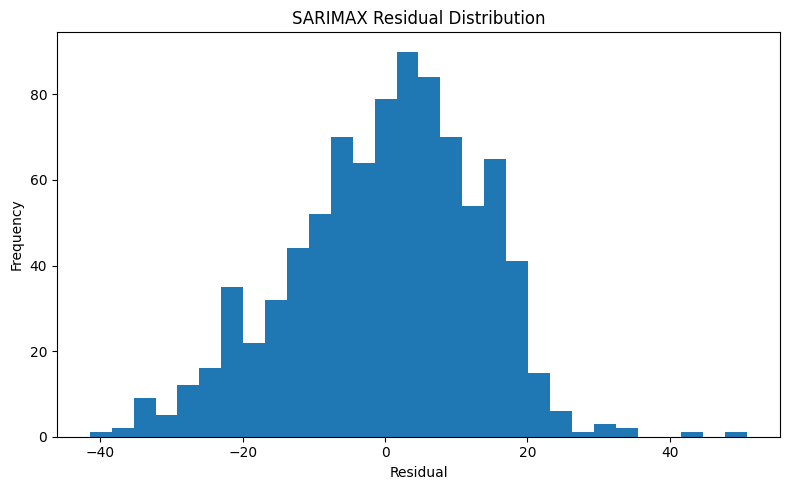

In [66]:
plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("SARIMAX Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title("SARIMAX Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [67]:
print("Ljung-Box p-value:", lb_test["lb_pvalue"].iloc[0])

if lb_test["lb_pvalue"].iloc[0] > 0.05:
    print("Residuals show no strong evidence of autocorrelation.")
else:
    print("Residuals may still contain autocorrelation.")


print("Jarque-Bera p-value:", jb_pvalue)

if jb_pvalue > 0.05:
    print("Residuals are approximately normally distributed.")
else:
    print("Residuals are likely not normally distributed.")

Ljung-Box p-value: 0.5736595902113579
Residuals show no strong evidence of autocorrelation.
Jarque-Bera p-value: 0.0007782513796037254
Residuals are likely not normally distributed.


In [68]:
# save sarimax model
model_save_path = Path.Path("../reports/sarimax_model.pkl")

best_model.remove_data()

with open(model_save_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"SARIMAX model saved to {model_save_path}")

SARIMAX model saved to ../reports/sarimax_model.pkl


In [69]:
# save forecast visualization
forecast_plot_path = Path.Path("../reports/sarimax_forecast.png")

plt.figure(figsize=(12, 6))
plt.plot(y_test_8w.index, y_test_8w, label="Actual", linewidth=2)
plt.plot(y_test_8w.index, forecast, label="Forecast", linewidth=2)

plt.title(f"SARIMAX Forecast vs Actuals - {site_id}")
plt.xlabel("Date")
plt.ylabel("Consumed Tonnes")
plt.legend()
plt.tight_layout()
plt.savefig(forecast_plot_path, dpi=160)
plt.close()


# save markdown report
report_path = Path.Path("../reports/baseline_model_results.md")

report = f"""# Baseline Model Results

## Model Overview

This report documents the SARIMAX baseline model for cement consumption forecasting.

## Dataset Setup

- Site ID: `{site_id}`
- Target variable: `consumed_tonnes`
- Exogenous variables:
  - `planned_pour_tonnes`
  - `rain_mm`
  - `avg_temp_c`
- Training observations: {len(y_train)}
- Forecast/test observations: {len(y_test_8w)}
- Forecast horizon: {len(y_test_8w)} days

## Hyperparameters

- Model type: `SARIMAX`
- order: `{best_order}`
- seasonal_order: `{best_seasonal_order}`
- AIC: {best_aic:.4f}
- enforce_stationarity: `False`
- enforce_invertibility: `False`

## Performance Metrics

| Metric | Value |
| --- | ---: |
| MAPE | {mape:.2f}% |
| RMSE | {rmse:.2f} tonnes |

## Forecast Visualization

![SARIMAX Forecast](sarimax_forecast.png)

## Diagnostic Tests

| Test | Value | Interpretation |
| --- | ---: | --- |
| Ljung-Box p-value, lag 10 | {lb_test["lb_pvalue"].iloc[0]:.6f} | Higher values suggest less remaining autocorrelation in residuals. |
| Jarque-Bera normality p-value | {jb_pvalue:.6f} | Higher values suggest residuals are closer to normally distributed. |

## Artifacts

- Forecast visualization: `sarimax_forecast.png`
- Report: `baseline_model_results.md`
"""

report_path.write_text(report, encoding="utf-8")

print(f"Saved baseline model report to: {report_path}")
print(f"Saved forecast visualization to: {forecast_plot_path}")

Saved baseline model report to: ../reports/baseline_model_results.md
Saved forecast visualization to: ../reports/sarimax_forecast.png


### XGBoost Model

XGBoost Forecast vs Actuals for SITE_001


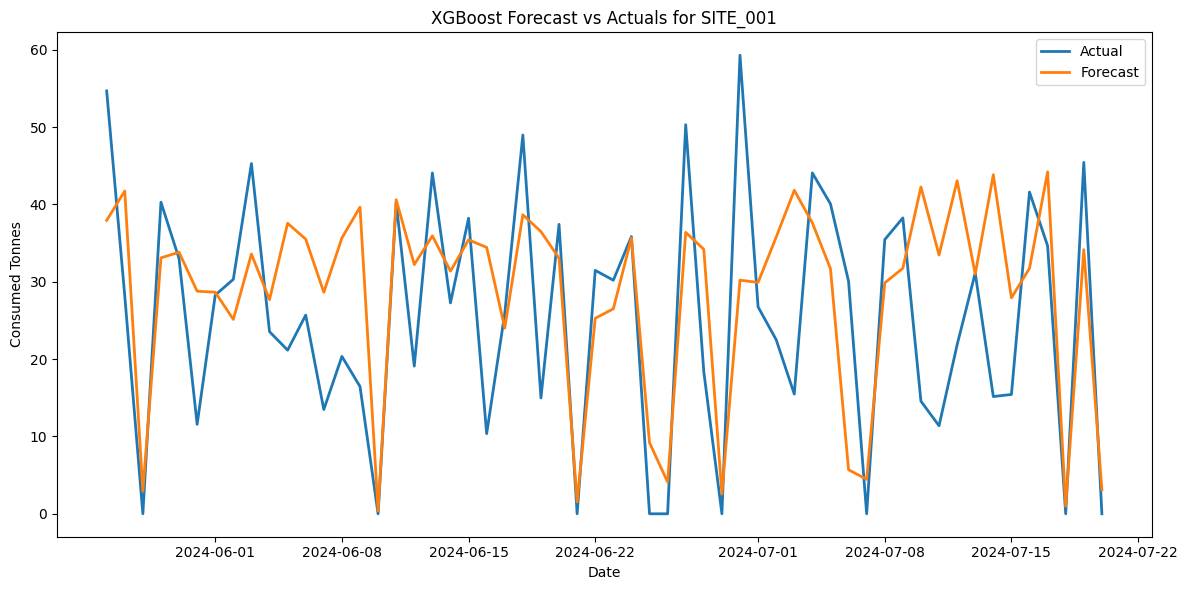

XGBoost MAPE: 57.33
XGBoost RMSE: 14.44


In [70]:
# xgboost model for one site
from xgboost import XGBRegressor

site_id = 'SITE_001'

site_df = df[df['site_id'] == site_id].copy()
site_df = site_df.set_index('date')
site_df = site_df.sort_values('date')

y = site_df['consumed_tonnes']
x = site_df[['planned_pour_tonnes', 'rain_mm', 'avg_temp_c']]

# split train test data
split_index = int(len(site_df) * 0.8)
y_train, X_train = y.iloc[:split_index], x.iloc[:split_index]
y_test, X_test = y.iloc[split_index:], x.iloc[split_index:]

# forcast horizon 56 days
forecast_horizon = 56

y_test_8w = y_test.iloc[:forecast_horizon]
X_test_8w = X_test.iloc[:forecast_horizon]

# train xgboost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test_8w)

# MAPE and RMSE for xgboost model
mask = y_test_8w != 0

xgb_mape = np.mean(
    np.abs((y_test_8w[mask] - xgb_forecast[mask]) / y_test_8w[mask])
    ) * 100

xgb_rmse = np.sqrt(
    mean_squared_error(y_test_8w[mask], xgb_forecast[mask])
)

print("XGBoost Forecast vs Actuals for SITE_001")
plt.figure(figsize=(12, 6))
plt.plot(y_test_8w.index, y_test_8w, label="Actual", linewidth=2)
plt.plot(y_test_8w.index, xgb_forecast, label="Forecast", linewidth=2)
plt.title(f"XGBoost Forecast vs Actuals for {site_id}")
plt.xlabel("Date")
plt.ylabel("Consumed Tonnes")
plt.legend()
plt.tight_layout()
plt.show()

print("XGBoost MAPE:", round(xgb_mape, 2))
print("XGBoost RMSE:", round(xgb_rmse, 2))



In [71]:
# Wrap up the xgboost model for all sites
xgb_sites_metrics = []
xgb_sites_predictions = []
xgb_feature_importance_df = []

for site_id in df['site_id'].unique():
    try:
        site_df = df[df['site_id'] == site_id].copy()
        site_df = site_df.set_index('date')
        site_df = site_df.sort_values('date')

        y = site_df['consumed_tonnes']
        x = site_df[['planned_pour_tonnes', 'rain_mm', 'avg_temp_c']]

        split_index = int(len(site_df) * 0.8)
        y_train, X_train = y.iloc[:split_index], x.iloc[:split_index]
        y_test, X_test = y.iloc[split_index:], x.iloc[split_index:]

        forecast_horizon = 56

        y_test_8w = y_test.iloc[:forecast_horizon]
        X_test_8w = X_test.iloc[:forecast_horizon]

        xgb_model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            n_jobs=-1
        )

        xgb_model.fit(X_train, y_train)

        xgb_forecast = xgb_model.predict(X_test_8w)

        site_predictions = pd.DataFrame({
            'site_id': site_id,
            'date': y_test_8w.index,
            'actual_consumed_tonnes': y_test_8w.values,
            'forecasted_consumed_tonnes': xgb_forecast
        })

        xgb_sites_predictions.append(site_predictions)

        mask = y_test_8w != 0

        mape = np.mean(
            np.abs((y_test_8w[mask] - xgb_forecast[mask]) / y_test_8w[mask])
        ) * 100

        rmse = np.sqrt(
            mean_squared_error(y_test_8w[mask], xgb_forecast[mask])
        )

        xgb_sites_metrics.append({
            'site_id': site_id,
            'MAPE': round(mape, 2),
            'RMSE': round(rmse, 2)
        })

        # feature importance for all sites

        for feature, importance in zip(X_train.columns, xgb_model.feature_importances_):
            xgb_feature_importance_df.append({
                'site_id': site_id,
                'feature': feature,
                'importance': importance
            })

    except Exception as e:
        print(f"Error processing site {site_id}: {e}")

In [72]:
# print the metrics for all sites and overall metrics
xgb_sites_metrics_df = pd.DataFrame(xgb_sites_metrics)
print(xgb_sites_metrics_df)
print("Overall MAPE:", round(xgb_sites_metrics_df['MAPE'].mean(), 2))
print("Overall RMSE:", round(xgb_sites_metrics_df['RMSE'].mean(), 2))


     site_id   MAPE   RMSE
0   SITE_001  57.33  14.44
1   SITE_002   0.97   0.14
2   SITE_003  26.69  11.40
3   SITE_004   4.28   0.91
4   SITE_005  29.63  11.51
5   SITE_006  17.47   7.22
6   SITE_007  37.96  11.68
7   SITE_008  35.81  10.74
8   SITE_009   1.04   0.17
9   SITE_010  40.93  11.45
10  SITE_011  30.83  10.39
11  SITE_012   0.83   0.13
12  SITE_013  11.90   6.36
13  SITE_014   3.77   2.30
14  SITE_015   2.59   0.69
15  SITE_016  16.03   6.46
16  SITE_017  38.68  10.69
17  SITE_018  34.56  10.39
18  SITE_019   1.12   0.18
19  SITE_020  31.50   9.33
20  SITE_021  37.15  12.14
21  SITE_022  38.76  10.87
22  SITE_023   4.54   0.96
23  SITE_024   4.46   2.55
24  SITE_025  41.27  12.61
25  SITE_026   6.45   4.67
26  SITE_027   0.95   0.12
27  SITE_028   6.98   4.44
28  SITE_029   0.91   0.11
29  SITE_030  58.41  13.85
Overall MAPE: 20.79
Overall RMSE: 6.63


In [73]:
# print the predictions for all sites
xgb_sites_predictions_df = pd.concat(
    xgb_sites_predictions, 
    ignore_index=True
)
print(xgb_sites_predictions_df)

       site_id       date  actual_consumed_tonnes  forecasted_consumed_tonnes
0     SITE_001 2024-05-26                   54.68                   37.940792
1     SITE_001 2024-05-27                   28.18                   41.731857
2     SITE_001 2024-05-28                    0.00                    2.940577
3     SITE_001 2024-05-29                   40.29                   33.089996
4     SITE_001 2024-05-30                   32.99                   33.823055
...        ...        ...                     ...                         ...
1675  SITE_030 2024-07-16                   34.03                   32.460083
1676  SITE_030 2024-07-17                   14.82                   28.450602
1677  SITE_030 2024-07-18                   40.22                   36.440762
1678  SITE_030 2024-07-19                   38.43                   35.244156
1679  SITE_030 2024-07-20                   45.83                   36.209167

[1680 rows x 4 columns]


In [74]:
# compare SARIMAX and XGBoost metrics for all sites
comparison_df = sarimax_sites_metrics_df.merge(
    xgb_sites_metrics_df,
    on='site_id',
    suffixes=('_sarimax', '_xgboost')
)
print(comparison_df)

# compare SARIMAX and XGBoost overall metrics
overall_comparison = pd.DataFrame([{
  'site_id': 'Overall',
  'MAPE_sarimax': round(sarimax_sites_metrics_df[sarimax_sites_metrics_df['site_id'] == 'Overall']['MAPE'].values[0], 2),
  'RMSE_sarimax': round(sarimax_sites_metrics_df[sarimax_sites_metrics_df['site_id'] == 'Overall']['RMSE'].values[0], 2),
  'MAPE_xgboost': round(xgb_sites_metrics_df['MAPE'].mean(), 2),
  'RMSE_xgboost': round(xgb_sites_metrics_df['RMSE'].mean(), 2)
}])
print(overall_comparison)

     site_id  MAPE_sarimax  RMSE_sarimax  MAPE_xgboost  RMSE_xgboost
0   SITE_001         53.88         13.21         57.33         14.44
1   SITE_002          3.78          0.50          0.97          0.14
2   SITE_003         27.52         10.44         26.69         11.40
3   SITE_004          3.35          0.44          4.28          0.91
4   SITE_005         30.60         11.85         29.63         11.51
5   SITE_006         25.61         10.04         17.47          7.22
6   SITE_007         37.55         10.95         37.96         11.68
7   SITE_008         35.72         11.57         35.81         10.74
8   SITE_009          3.37          0.48          1.04          0.17
9   SITE_010         45.32         13.46         40.93         11.45
10  SITE_011         32.05         10.95         30.83         10.39
11  SITE_012          3.10          0.44          0.83          0.13
12  SITE_013         19.25          7.13         11.90          6.36
13  SITE_014         12.86        

In [75]:
# feature importance for XGBoost model for SITE_001
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
0,planned_pour_tonnes,0.461801
1,rain_mm,0.435043
2,avg_temp_c,0.103156


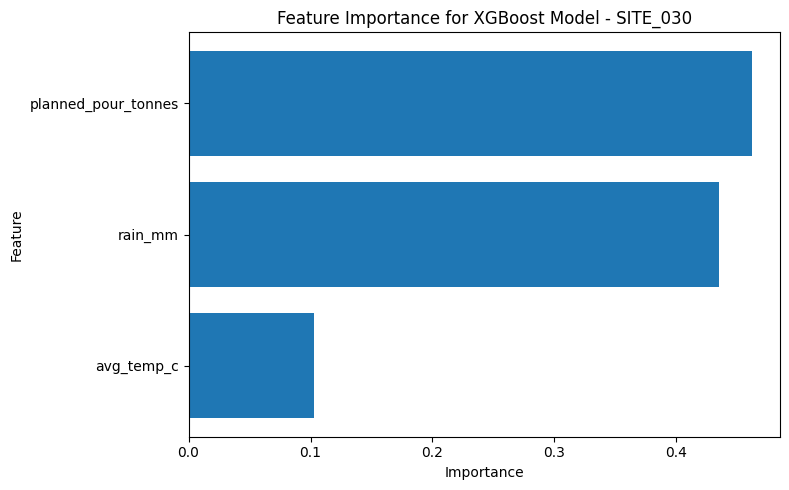

In [76]:
# plot feature importance for XGBoost model for SITE_001
plt.figure(figsize=(8, 5))

plt.barh(
  feature_importance_df['feature'],
  feature_importance_df['importance']
)
plt.gca().invert_yaxis()  
plt.title(f"Feature Importance for XGBoost Model - {site_id}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [77]:
# feature importance for XGBoost model for all sites
xgb_feature_importance_df = pd.DataFrame(xgb_feature_importance_df)

overall_feature_importance_df = (
xgb_feature_importance_df.groupby('feature')['importance']
.mean()
.reset_index()
.sort_values('importance', ascending=False)
)

overall_feature_importance_df

,feature,importance
1,planned_pour_tonnes,0.671320
2,rain_mm,0.255974
0,avg_temp_c,0.072706


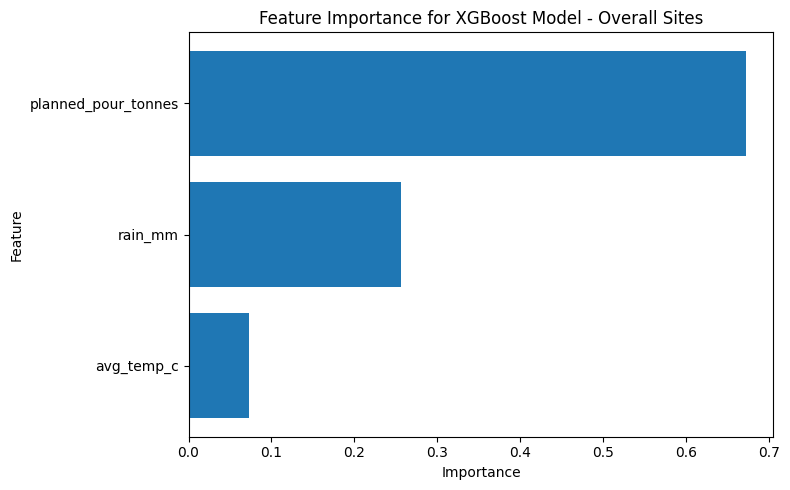

In [78]:
# plot feature importance for XGBoost model for overall sites
plt.figure(figsize=(8, 5))

plt.barh(
  overall_feature_importance_df['feature'],
  overall_feature_importance_df['importance']
)

plt.gca().invert_yaxis()
plt.title("Feature Importance for XGBoost Model - Overall Sites")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [79]:
# save xgboost model in pickle format
xgb_model_save_path = Path.Path("../reports/xgboost_model.pkl")

with open(xgb_model_save_path, 'wb') as f:
    pickle.dump(xgb_model, f)

print(f"XGBoost model saved to {xgb_model_save_path}")

XGBoost model saved to ../reports/xgboost_model.pkl
